In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings("ignore")

In [22]:
data = pd.read_csv("/content/heart(1).xls")
print("Shape:", data.shape)
print(data.head())
print(data.info())
print(data.describe())
print("\nMissing Values:\n", data.isnull().sum())

Shape: (1025, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 no

In [23]:
data.drop_duplicates(inplace=True)
print("After duplicates:", data.shape)

After duplicates: (302, 14)


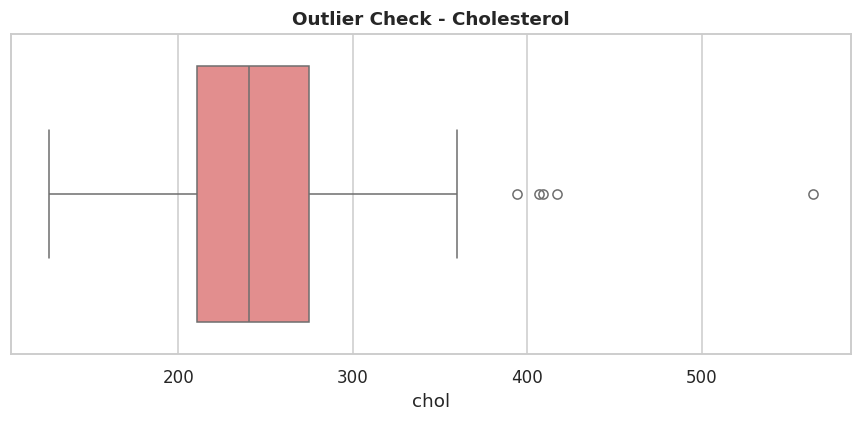

In [24]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=data["chol"], color="lightcoral")
plt.title("Outlier Check - Cholesterol", fontweight="bold")
plt.tight_layout()
plt.savefig("outlier_chol.png", bbox_inches="tight")
plt.show()

In [25]:
data["age_group"] = pd.cut(data["age"],
                            bins=[20, 40, 50, 60, 70, 80],
                            labels=["20-40","40-50","50-60","60-70","70-80"])

cp_map   = {0:"Typical Angina", 1:"Atypical Angina",
            2:"Non-anginal Pain", 3:"Asymptomatic"}
thal_map = {0:"Unknown", 1:"Normal",
            2:"Fixed Defect", 3:"Reversible Defect"}

print("\nCleaning Done! Shape:", data.shape)


Cleaning Done! Shape: (302, 15)


In [26]:
# Average age
print("\n[B1] Avg Age:", round(data["age"].mean(), 2))


[B1] Avg Age: 54.42


In [27]:
# Gender distribution
gc = data["sex"].value_counts()
gc.index = ["Male" if i==1 else "Female" for i in gc.index]
print("\n[B2] Gender Distribution:\n", gc.to_string())


[B2] Gender Distribution:
 Male      206
Female     96


In [28]:
# Average resting BP
print("\n[B3] Avg Resting BP:", round(data["trestbps"].mean(), 2), "mmHg")


[B3] Avg Resting BP: 131.6 mmHg


In [29]:
#  Fasting blood sugar > 120
print("\n[B4] FBS > 120 count:", data["fbs"].sum(),
      f"({round(data['fbs'].mean()*100,1)}%)")


[B4] FBS > 120 count: 45 (14.9%)


In [30]:
# Chest pain types
print("\n[B5] Chest Pain Types:\n",
      data["cp"].value_counts().rename(index=cp_map).to_string())


[B5] Chest Pain Types:
 cp
Typical Angina      143
Non-anginal Pain     86
Atypical Angina      50
Asymptomatic         23


In [31]:
#  Max heart rate
print("\n[B6] Max Heart Rate:", data["thalach"].max(), "bpm")


[B6] Max Heart Rate: 202 bpm


In [32]:
#  Exercise induced angina %
print("\n[B7] Exercise-Induced Angina:", round(data["exang"].mean()*100, 1), "%")


[B7] Exercise-Induced Angina: 32.8 %


In [33]:
#  Avg cholesterol
print("\n[B8] Avg Cholesterol:", round(data["chol"].mean(), 2), "mg/dl")


[B8] Avg Cholesterol: 246.5 mg/dl


In [34]:
#  Restecg = 2
print("\n[B9] Restecg=2 count:", (data["restecg"]==2).sum())
print("     ECG distribution:\n", data["restecg"].value_counts().to_string())


[B9] Restecg=2 count: 4
     ECG distribution:
 restecg
1    151
0    147
2      4


In [35]:
#  Major vessels distribution
print("\n[B10] Major Vessels (ca):\n",
      data["ca"].value_counts().sort_index().to_string())



[B10] Major Vessels (ca):
 ca
0    175
1     65
2     38
3     20
4      4


MEDIUM QUESTIONS


In [36]:
#  Correlation age vs cholesterol
print("\n[M1] Age vs Cholesterol Correlation:\n",
      data[["age","chol"]].corr().to_string())


[M1] Age vs Cholesterol Correlation:
            age      chol
age   1.000000  0.207216
chol  0.207216  1.000000



[M2] Chest Pain by Age Group:
            Typical Angina  Atypical Angina  Non-anginal Pain  Asymptomatic
age_group                                                                 
20-40                 6.0              3.0               6.0           3.0
40-50                29.0             20.0              25.0           2.0
50-60                65.0             20.0              34.0          10.0
60-70                41.0              5.0              19.0           8.0
70-80                 2.0              2.0               2.0           0.0


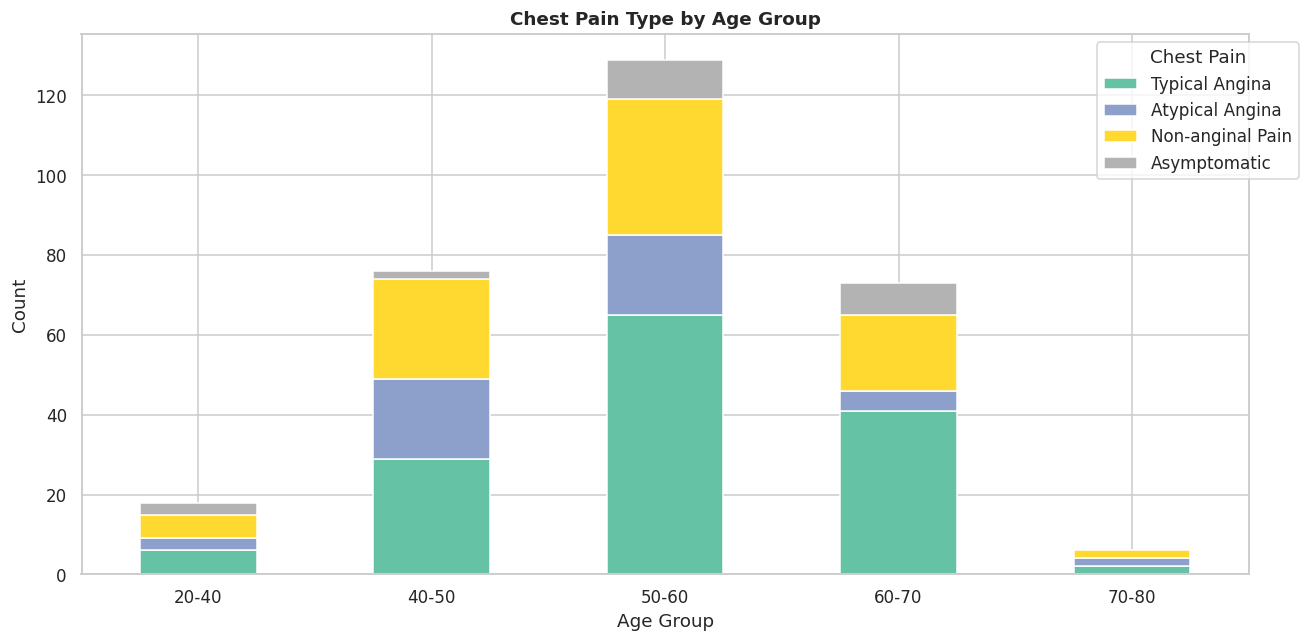

In [37]:
# Chest pain by age group (chart)
cp_age = data.groupby("age_group", observed=True)["cp"].value_counts().unstack().fillna(0)
cp_age.columns = [cp_map.get(c,c) for c in cp_age.columns]
print("\n[M2] Chest Pain by Age Group:\n", cp_age.to_string())

cp_age.plot(kind="bar", stacked=True, figsize=(12,6),
            colormap="Set2", edgecolor="white")
plt.title("Chest Pain Type by Age Group", fontweight="bold")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Chest Pain", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.savefig("m2_cp_age.png", bbox_inches="tight")
plt.show()

In [38]:
#  Max heart rate vs exercise angina
hr = data.groupby("exang")["thalach"].mean()
hr.index = ["No Angina","Exercise Angina"]
print("\n[M3] Avg Heart Rate vs Exercise Angina:\n", hr.to_string())



[M3] Avg Heart Rate vs Exercise Angina:
 No Angina          155.596059
Exercise Angina    137.212121


In [39]:
# BP by gender
bp = data.groupby("sex")["trestbps"].mean()
bp.index = ["Female","Male"]
print("\n[M4] Avg Resting BP by Gender:\n", bp.to_string())



[M4] Avg Resting BP by Gender:
 Female    133.083333
Male      130.912621



[M5] FBS vs Heart Disease:
                  No Disease  Heart Disease
FBS Normal              116            141
FBS High (>120)          22             23


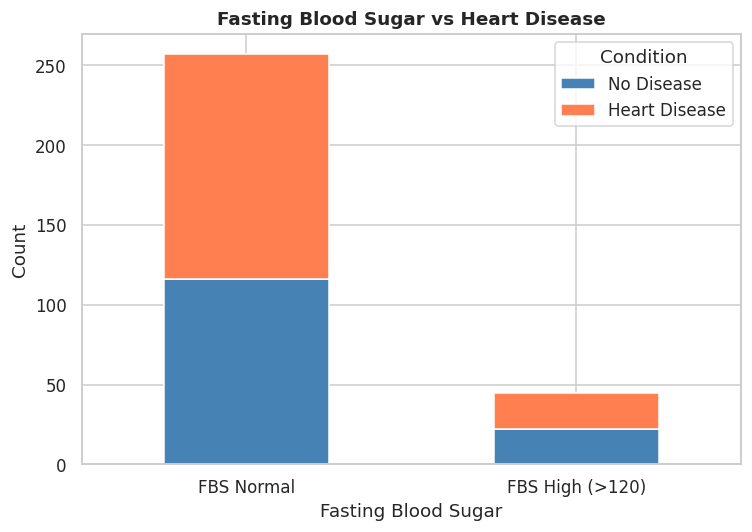

In [40]:
#  FBS vs heart disease (chart)
ct1 = pd.crosstab(data["fbs"], data["target"])
ct1.index = ["FBS Normal","FBS High (>120)"]
ct1.columns = ["No Disease","Heart Disease"]
print("\n[M5] FBS vs Heart Disease:\n", ct1.to_string())

ct1.plot(kind="bar", stacked=True, figsize=(7,5),
         color=["steelblue","coral"], edgecolor="white")
plt.title("Fasting Blood Sugar vs Heart Disease", fontweight="bold")
plt.xlabel("Fasting Blood Sugar")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Condition")
plt.tight_layout()
plt.savefig("m5_fbs_target.png", bbox_inches="tight")
plt.show()



[M6] Major Vessels vs Heart Disease:
     No Disease  Heart Disease
ca                           
0           45            130
1           44             21
2           31              7
3           17              3
4            1              3


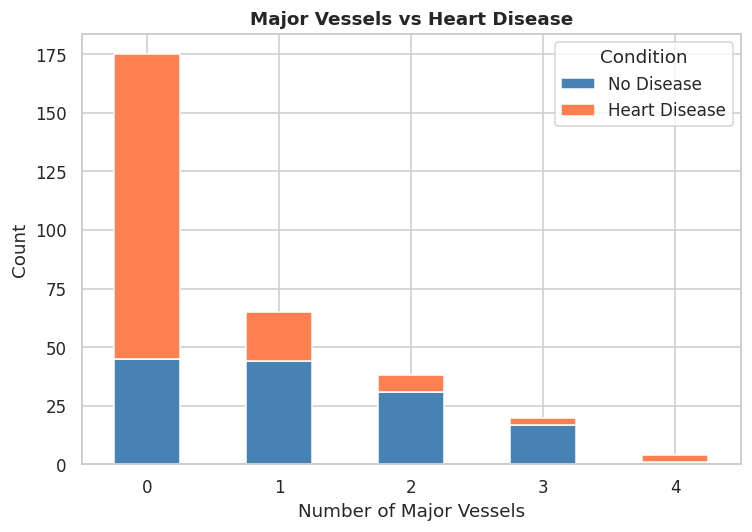

In [41]:
#  Major vessels vs heart disease (chart)
ct2 = pd.crosstab(data["ca"], data["target"])
ct2.columns = ["No Disease","Heart Disease"]
print("\n[M6] Major Vessels vs Heart Disease:\n", ct2.to_string())

ct2.plot(kind="bar", stacked=True, figsize=(7,5),
         color=["steelblue","coral"], edgecolor="white")
plt.title("Major Vessels vs Heart Disease", fontweight="bold")
plt.xlabel("Number of Major Vessels")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Condition")
plt.tight_layout()
plt.savefig("m6_ca_target.png", bbox_inches="tight")
plt.show()

In [42]:
#  Oldpeak vs chest pain
print("\n[M7] Avg Oldpeak by Chest Pain:\n",
      data.groupby("cp")["oldpeak"].mean().rename(index=cp_map).to_string())


[M7] Avg Oldpeak by Chest Pain:
 cp
Typical Angina      1.383217
Atypical Angina     0.316000
Non-anginal Pain    0.806977
Asymptomatic        1.391304



[M8] Thalassemia vs Heart Disease:
                    No Disease  Heart Disease
Unknown                     1              1
Normal                     12              6
Fixed Defect               36            129
Reversible Defect          89             28


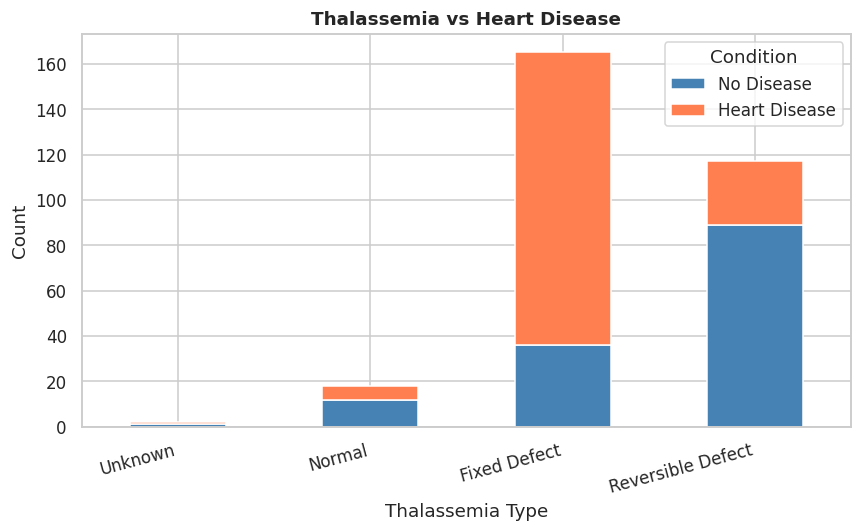

In [43]:
#  Thalassemia vs heart disease (chart)
ct3 = pd.crosstab(data["thal"], data["target"])
ct3.index = [thal_map.get(i,i) for i in ct3.index]
ct3.columns = ["No Disease","Heart Disease"]
print("\n[M8] Thalassemia vs Heart Disease:\n", ct3.to_string())

ct3.plot(kind="bar", stacked=True, figsize=(8,5),
         color=["steelblue","coral"], edgecolor="white")
plt.title("Thalassemia vs Heart Disease", fontweight="bold")
plt.xlabel("Thalassemia Type")
plt.ylabel("Count")
plt.xticks(rotation=15, ha="right")
plt.legend(title="Condition")
plt.tight_layout()
plt.savefig("m8_thal_target.png", bbox_inches="tight")
plt.show()

In [44]:
#  Common risk combinations in heart disease patients
risk = (
    data[data["target"]==1]
    .groupby(["cp","fbs","exang","thal"])
    .size().reset_index(name="counts")
    .sort_values("counts", ascending=False)
    .head(10)
)
risk["cp"]    = risk["cp"].map(cp_map)
risk["thal"]  = risk["thal"].map(thal_map)
risk["fbs"]   = risk["fbs"].map({0:"Normal FBS", 1:"High FBS"})
risk["exang"] = risk["exang"].map({0:"No Angina", 1:"Angina"})
print("\n[M9] Top 10 Risk Factor Combos:\n", risk.to_string(index=False))


[M9] Top 10 Risk Factor Combos:
               cp        fbs     exang              thal  counts
Non-anginal Pain Normal FBS No Angina      Fixed Defect      41
 Atypical Angina Normal FBS No Angina      Fixed Defect      30
  Typical Angina Normal FBS No Angina      Fixed Defect      23
Non-anginal Pain   High FBS No Angina      Fixed Defect      10
  Typical Angina Normal FBS    Angina      Fixed Defect       6
Non-anginal Pain Normal FBS No Angina Reversible Defect       6
    Asymptomatic Normal FBS No Angina      Fixed Defect       5
 Atypical Angina Normal FBS No Angina Reversible Defect       4
Non-anginal Pain Normal FBS    Angina      Fixed Defect       4
Non-anginal Pain   High FBS No Angina Reversible Defect       3


In [45]:
#  Heart disease rate by age group
hd = (data.groupby("age_group", observed=True)["target"].mean()*100).reset_index()
hd.columns = ["Age Group","Heart Disease Rate (%)"]
print("\n[M10] Heart Disease Rate by Age Group:\n", hd.to_string(index=False))



[M10] Heart Disease Rate by Age Group:
 Age Group  Heart Disease Rate (%)
    20-40               66.666667
    40-50               69.736842
    50-60               49.612403
    60-70               41.095890
    70-80               83.333333


ADVANCED QUESTIONS


[A1] Pairplot generating...


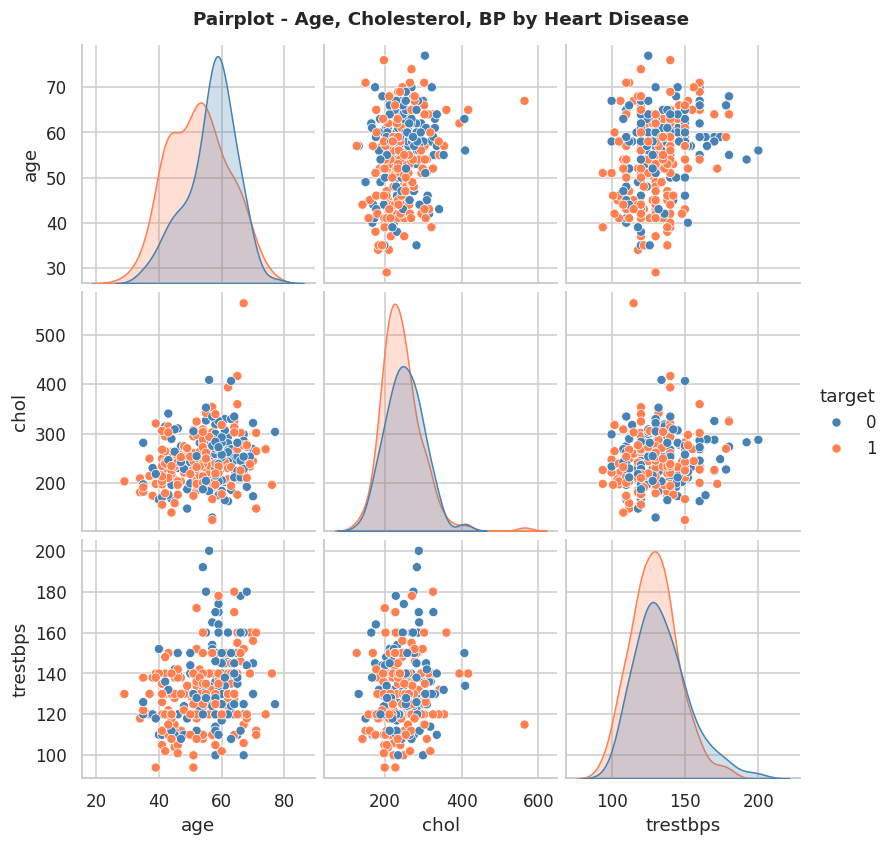

In [46]:
#  Pairplot (chart)
print("\n[A1] Pairplot generating...")
sns.pairplot(data[["age","chol","trestbps","target"]],
             hue="target", palette=["steelblue","coral"])
plt.suptitle("Pairplot - Age, Cholesterol, BP by Heart Disease",
             y=1.02, fontsize=12, fontweight="bold")
plt.savefig("a1_pairplot.png", bbox_inches="tight")
plt.show()

In [47]:
#  Feature correlations with target
corr = data.drop(columns=["age_group"]).corr()["target"].drop("target")
print("\n[A2] Feature Correlations with Heart Disease:\n",
      corr.sort_values(ascending=False).to_string())


[A2] Feature Correlations with Heart Disease:
 cp          0.432080
thalach     0.419955
slope       0.343940
restecg     0.134874
fbs        -0.026826
chol       -0.081437
trestbps   -0.146269
age        -0.221476
sex        -0.283609
thal       -0.343101
ca         -0.408992
oldpeak    -0.429146
exang      -0.435601


In [48]:
#  Random Forest Model
print("\n[A3] Random Forest - Predicting Heart Disease:")
features = ["age","sex","cp","trestbps","chol","fbs",
            "restecg","thalach","exang","oldpeak","slope","ca","thal"]
X = data[features]
y = data["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=7)
model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")


[A3] Random Forest - Predicting Heart Disease:
              precision    recall  f1-score   support

           0       0.92      0.86      0.89        14
           1       0.89      0.94      0.91        17

    accuracy                           0.90        31
   macro avg       0.91      0.90      0.90        31
weighted avg       0.90      0.90      0.90        31

Confusion Matrix:
 [[12  2]
 [ 1 16]]
Accuracy: 90.32%


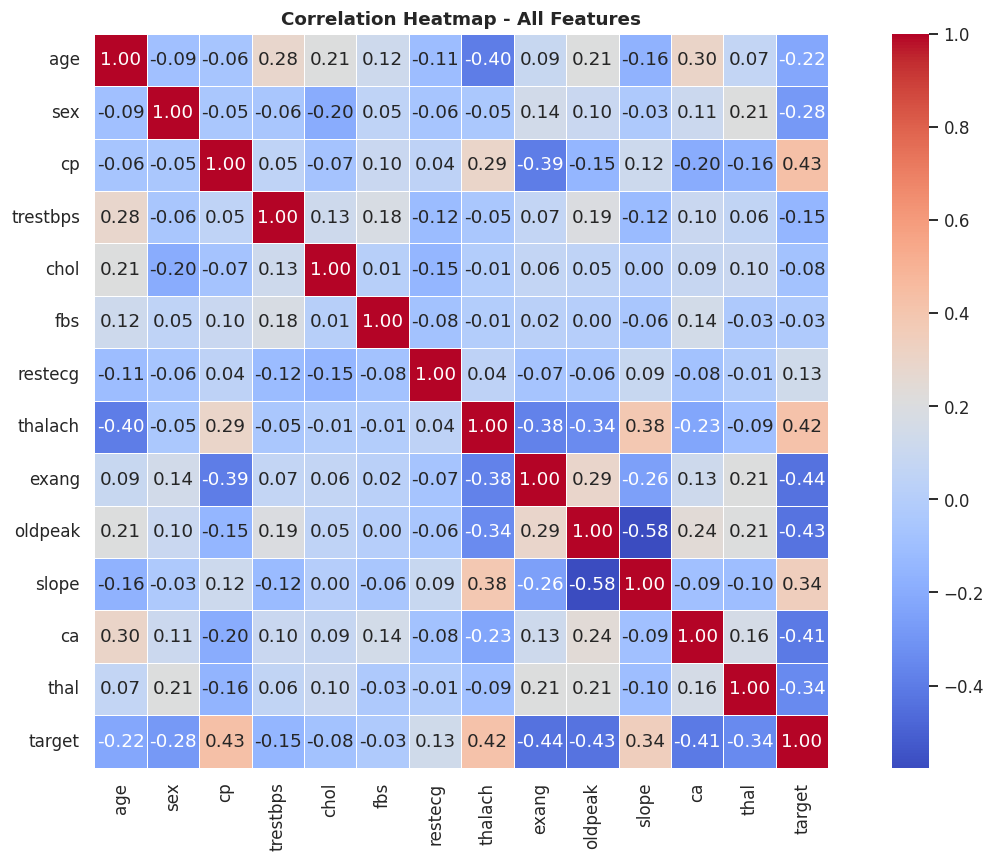

In [49]:
#  Correlation heatmap (chart)
plt.figure(figsize=(12,8))
sns.heatmap(data.drop(columns=["age_group"]).corr(),
            annot=True, fmt=".2f", cmap="coolwarm",
            square=True, linewidths=0.5)
plt.title("Correlation Heatmap - All Features", fontweight="bold")
plt.tight_layout()
plt.savefig("a4_heatmap.png", bbox_inches="tight")
plt.show()


[A5] Heart Disease Distribution:
 target
Heart Disease    164
No Disease       138


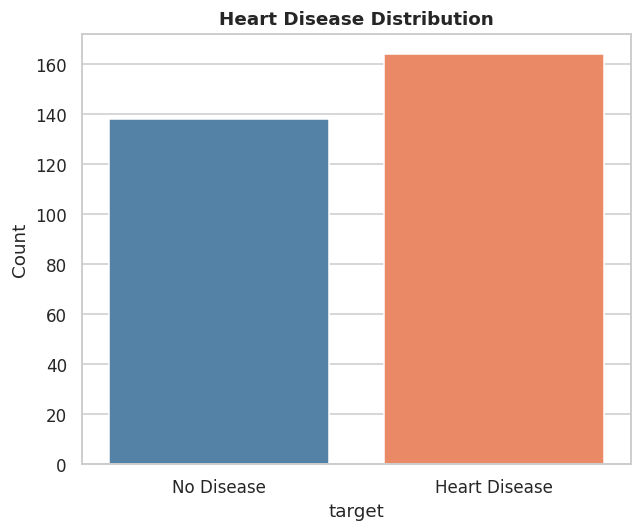

In [50]:
#  Target distribution (chart)
print("\n[A5] Heart Disease Distribution:\n",
      data["target"].value_counts()
      .rename(index={0:"No Disease",1:"Heart Disease"}).to_string())

plt.figure(figsize=(6,5))
ax = sns.countplot(x="target", data=data,
                   palette=["steelblue","coral"])
ax.set_xticks([0,1])
ax.set_xticklabels(["No Disease","Heart Disease"])
plt.title("Heart Disease Distribution", fontweight="bold")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("a5_target_dist.png", bbox_inches="tight")
plt.show()


FINAL SUMMARY

In [52]:
print("\n" + "="*50)
print("KEY INSIGHTS SUMMARY")
print("="*50)
print(f"Total Patients        : {data.shape[0]:,}")
print(f"Heart Disease Rate    : {data['target'].mean()*100:.1f}%")
print(f"Average Age           : {data['age'].mean():.2f} years")
print(f"Average Cholesterol   : {data['chol'].mean():.2f} mg/dl")
print(f"Avg Resting BP        : {data['trestbps'].mean():.2f} mmHg")
print(f"Max Heart Rate        : {data['thalach'].max()} bpm")
print(f"Exercise Angina       : {data['exang'].mean()*100:.1f}%")
print(f"High FBS              : {data['fbs'].mean()*100:.1f}%")
print(f"Model Accuracy        : {accuracy_score(y_test, y_pred)*100:.2f}%")


KEY INSIGHTS SUMMARY
Total Patients        : 302
Heart Disease Rate    : 54.3%
Average Age           : 54.42 years
Average Cholesterol   : 246.50 mg/dl
Avg Resting BP        : 131.60 mmHg
Max Heart Rate        : 202 bpm
Exercise Angina       : 32.8%
High FBS              : 14.9%
Model Accuracy        : 90.32%
